In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

DAILY_WEIGHTS_PATH = "../data/daily_weights.csv"
REBAL_WEIGHTS_PATH = "../data/target_weights_monthly.csv"
DIAGNOSTICS_PATH = "../data/rebalance_diagnostics.csv"
PRICES_PATH = "../data/etf_data_clean.csv"

In [15]:
# Load saved weights, prices, and diagnostics
daily_w = pd.read_csv(DAILY_WEIGHTS_PATH, index_col=0, parse_dates=True)
rebal_w = pd.read_csv(REBAL_WEIGHTS_PATH, index_col=0, parse_dates=True)
diag = pd.read_csv(DIAGNOSTICS_PATH, index_col=["date", "ticker"], parse_dates=["date"])
prices = pd.read_csv(PRICES_PATH, index_col=0, parse_dates=True)

display(daily_w.tail())
display(rebal_w.tail())
display(diag.tail())

,BWX,CORN,CPER,DBA,EMB,FXA,FXB,FXC,FXE,FXF,...,GLD,HYG,IEF,LQD,SHY,SLV,TLT,UNG,USO,WEAT
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-06,0.0,-0.182795,0.0,-0.337533,0.258238,0.0,0.092216,0.0,0.092738,0.069988,...,0.011129,0.0,0.0,0.0,0.471698,0.003994,-0.193259,-0.015398,0.0,-0.072125
2026-03-09,0.0,-0.182795,0.0,-0.337533,0.258238,0.0,0.092216,0.0,0.092738,0.069988,...,0.011129,0.0,0.0,0.0,0.471698,0.003994,-0.193259,-0.015398,0.0,-0.072125
2026-03-10,0.0,-0.182795,0.0,-0.337533,0.258238,0.0,0.092216,0.0,0.092738,0.069988,...,0.011129,0.0,0.0,0.0,0.471698,0.003994,-0.193259,-0.015398,0.0,-0.072125
2026-03-11,0.0,-0.182795,0.0,-0.337533,0.258238,0.0,0.092216,0.0,0.092738,0.069988,...,0.011129,0.0,0.0,0.0,0.471698,0.003994,-0.193259,-0.015398,0.0,-0.072125
2026-03-12,0.0,-0.182795,0.0,-0.337533,0.258238,0.0,0.092216,0.0,0.092738,0.069988,...,0.011129,0.0,0.0,0.0,0.471698,0.003994,-0.193259,-0.015398,0.0,-0.072125


,BWX,CORN,CPER,DBA,EMB,FXA,FXB,FXC,FXE,FXF,...,GLD,HYG,IEF,LQD,SHY,SLV,TLT,UNG,USO,WEAT
2025-11-03,0.0,-0.163005,0.0,0.000000,0.120237,0.0,0.000000,-0.48055,0.119797,0.000000,...,0.017203,0.133048,0.140684,0.0,0.455689,0.013342,-0.171966,-0.030008,-0.055518,-0.098953
2025-12-01,0.0,-0.172869,0.0,-0.164810,0.122598,0.0,0.000000,0.00000,0.115315,0.000000,...,0.025259,0.138324,0.107887,0.0,0.478829,0.011789,0.000000,-0.063680,-0.104078,-0.119425
2026-01-02,0.0,-0.174920,0.0,-0.321106,0.115745,0.0,0.000000,0.00000,0.112074,0.000000,...,0.020378,0.182129,0.123322,0.0,0.439654,0.006699,0.000000,-0.025494,-0.077050,-0.163107
2026-02-02,0.0,-0.144154,0.0,-0.366698,0.110207,0.0,0.057021,0.00000,0.052552,0.037085,...,0.009198,0.000000,0.000000,0.0,0.730654,0.003283,0.000000,-0.017622,-0.071410,-0.149458
2026-03-02,0.0,-0.182795,0.0,-0.337533,0.258238,0.0,0.092216,0.00000,0.092738,0.069988,...,0.011129,0.000000,0.000000,0.0,0.471698,0.003994,-0.193259,-0.015398,0.000000,-0.072125


raw_mom   vol_11m  mom_score  rank_pct    vol_1m    weight
date       ticker                                                             
2026-03-02 SLV     1.312985  0.375594   3.495759  1.000000  1.556696  0.003994
           TLT    -0.001269  0.115308  -0.011006  0.238095  0.093028 -0.193259
           UNG    -0.325791  0.588230  -0.553850  0.142857  1.167590 -0.015398
           USO     0.050004  0.317246   0.157619  0.333333  0.396074  0.000000
           WEAT   -0.147979  0.181957  -0.813267  0.047619  0.249269 -0.072125

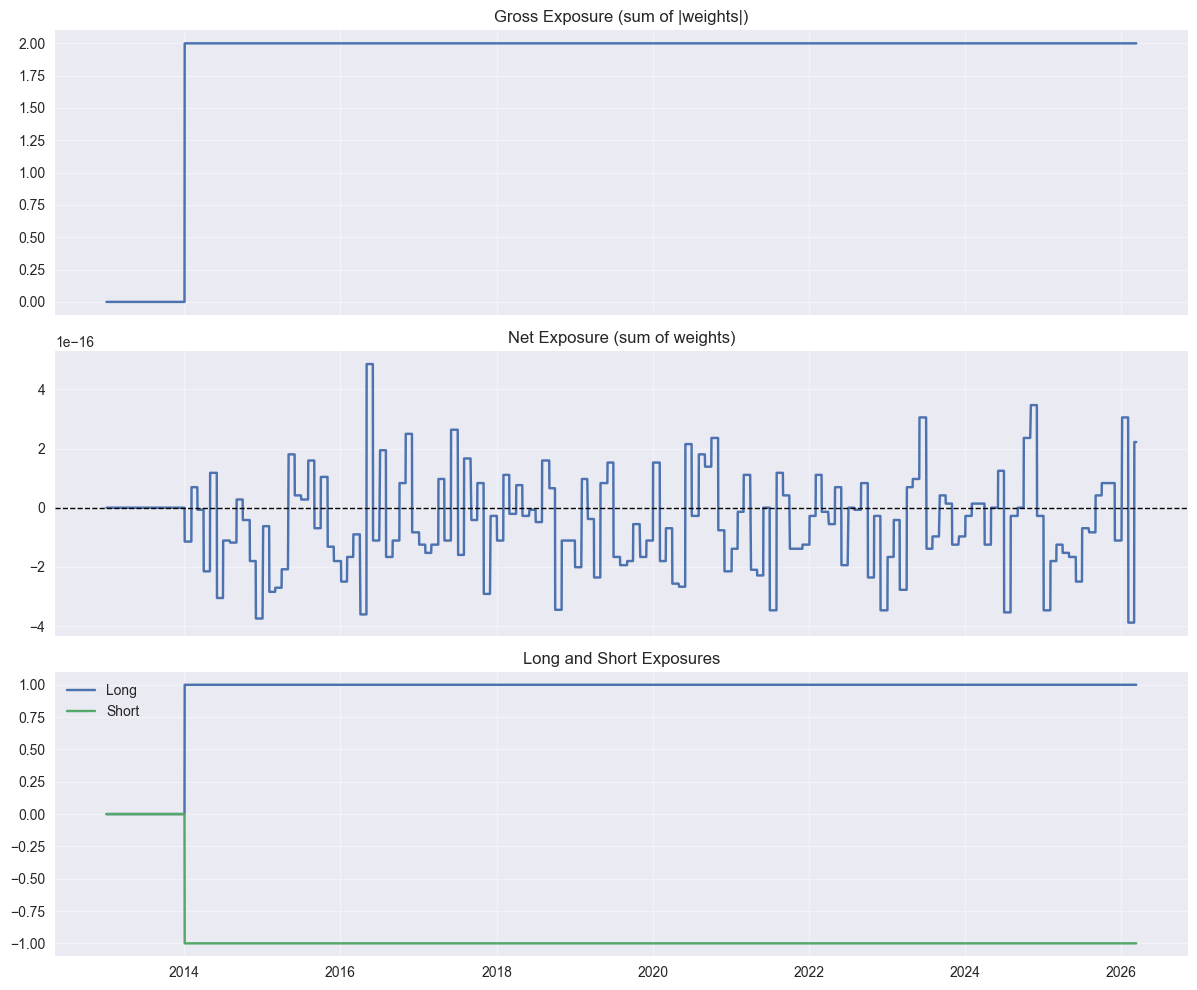

In [16]:
# Basic exposure sanity checks
gross_exposure = daily_w.abs().sum(axis=1)
net_exposure = daily_w.sum(axis=1)
long_exposure = daily_w.clip(lower=0).sum(axis=1)
short_exposure = daily_w.clip(upper=0).sum(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(gross_exposure)
axes[0].set_title("Gross Exposure (sum of |weights|)")
axes[0].grid(True, alpha=0.4)

axes[1].plot(net_exposure)
axes[1].set_title("Net Exposure (sum of weights)")
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].grid(True, alpha=0.4)

axes[2].plot(long_exposure, label="Long")
axes[2].plot(short_exposure, label="Short")
axes[2].set_title("Long and Short Exposures")
axes[2].grid(True, alpha=0.4)
axes[2].legend()

plt.tight_layout()
plt.show()

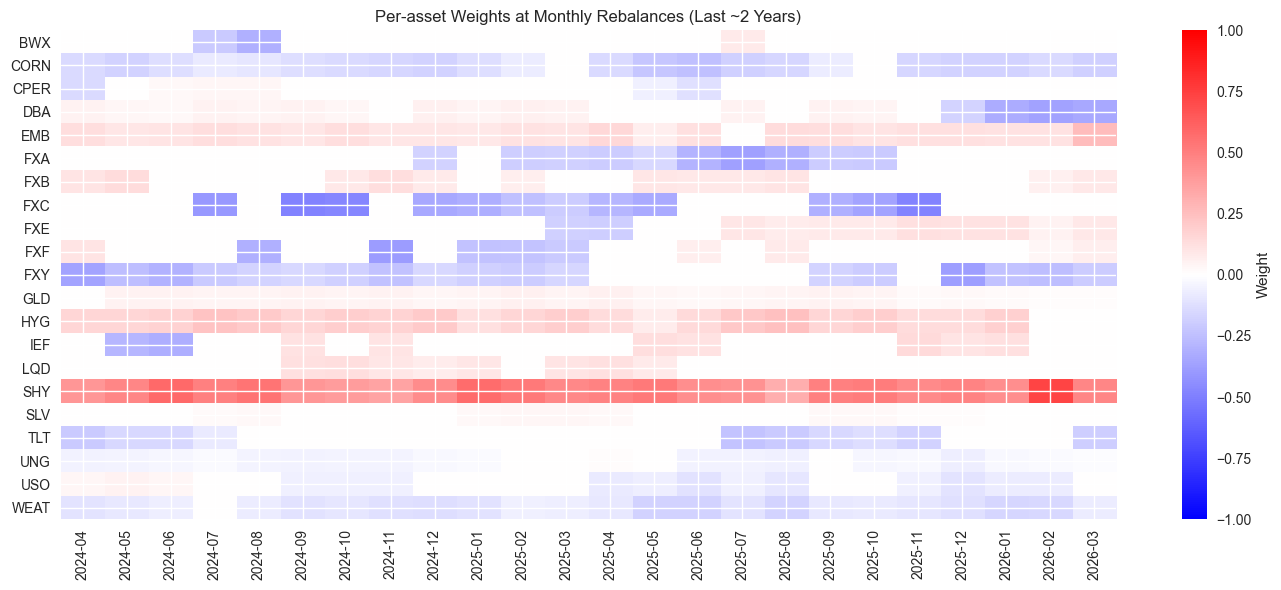

In [17]:
# Per-asset weights at rebalance dates (heatmap-style image)
subset = rebal_w.tail(24)  # last 24 rebalances (~2 years)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(subset.T, aspect="auto", cmap="bwr", vmin=-1, vmax=1)

ax.set_yticks(range(len(subset.columns)))
ax.set_yticklabels(subset.columns)
ax.set_xticks(range(len(subset.index)))
ax.set_xticklabels([d.strftime("%Y-%m") for d in subset.index], rotation=90)
ax.set_title("Per-asset Weights at Monthly Rebalances (Last ~2 Years)")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Weight")

plt.tight_layout()
plt.show()

In [18]:
# Inspect diagnostics for a single rebalance date
# Pick the latest rebalance
latest_date = diag.index.get_level_values("date").max()
latest_diag = diag.xs(latest_date, level="date")

print(f"Latest rebalance date: {latest_date.date()}")
display(latest_diag.sort_values("rank_pct", ascending=False).head(10))
display(latest_diag.sort_values("rank_pct", ascending=True).head(10))

Latest rebalance date: 2026-03-02


,raw_mom,vol_11m,mom_score,rank_pct,vol_1m,weight
ticker,,,,,,
SLV,1.312985,0.375594,3.495759,1.000000,1.556696,0.003994
GLD,0.626909,0.212881,2.944881,0.952381,0.558739,0.011129
SHY,0.040241,0.013973,2.879943,0.904762,0.013182,0.471698
FXE,0.147305,0.078702,1.871691,0.857143,0.067049,0.092738
FXB,0.112657,0.070309,1.602300,0.809524,0.067429,0.092216
FXF,0.155870,0.097660,1.596055,0.761905,0.088844,0.069988
EMB,0.101999,0.065816,1.549750,0.714286,0.024078,0.258238
FXA,0.132320,0.096897,1.365571,0.666667,0.100921,0.000000
FXC,0.072437,0.055520,1.304711,0.619048,0.051718,0.000000


,raw_mom,vol_11m,mom_score,rank_pct,vol_1m,weight
ticker,,,,,,
WEAT,-0.147979,0.181957,-0.813267,0.047619,0.249269,-0.072125
CORN,-0.104617,0.144697,-0.723012,0.095238,0.098353,-0.182795
UNG,-0.325791,0.588230,-0.553850,0.142857,1.167590,-0.015398
FXY,-0.026142,0.103257,-0.253174,0.190476,0.090395,-0.198889
TLT,-0.001269,0.115308,-0.011006,0.238095,0.093028,-0.193259
DBA,-0.000261,0.126644,-0.002065,0.285714,0.053264,-0.337533
USO,0.050004,0.317246,0.157619,0.333333,0.396074,0.000000
CPER,0.299549,0.377516,0.793475,0.380952,0.387577,0.000000
LQD,0.055595,0.064879,0.856912,0.428571,0.031595,0.000000


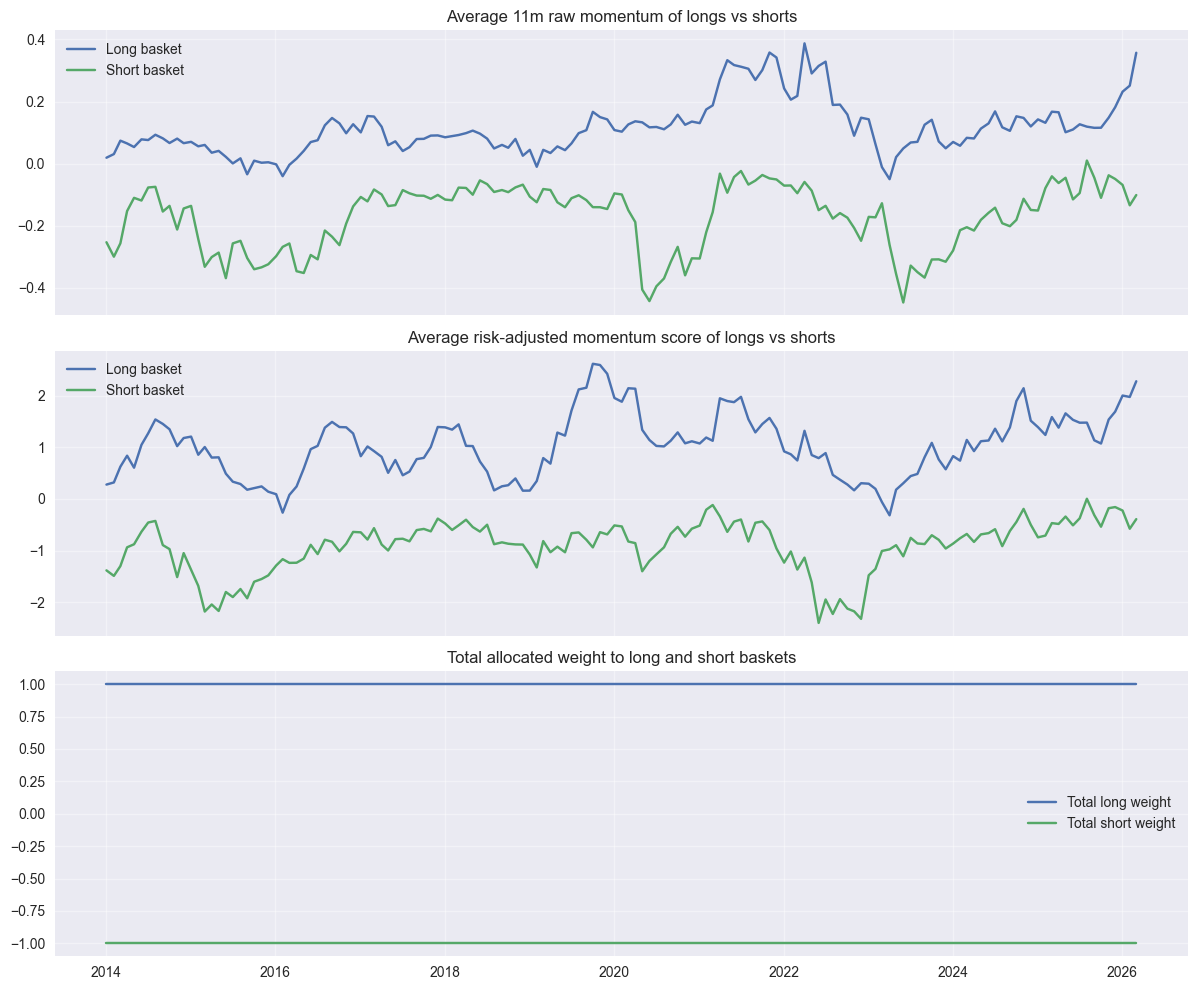

In [19]:
# Time-series of average raw momentum, risk-adjusted score, and weight for longs vs shorts

# Tag longs/shorts by rank cutoff per date
cut_long = 0.70
cut_short = 0.30

long_mask = diag["rank_pct"] >= cut_long
short_mask = diag["rank_pct"] <= cut_short

by_date = diag.reset_index().set_index("date")

agg = pd.DataFrame({
    "raw_long": by_date[long_mask.values].groupby(level=0)["raw_mom"].mean(),
    "raw_short": by_date[short_mask.values].groupby(level=0)["raw_mom"].mean(),
    "score_long": by_date[long_mask.values].groupby(level=0)["mom_score"].mean(),
    "score_short": by_date[short_mask.values].groupby(level=0)["mom_score"].mean(),
    "w_long": by_date[long_mask.values].groupby(level=0)["weight"].sum(),
    "w_short": by_date[short_mask.values].groupby(level=0)["weight"].sum(),
}).dropna(how="all")

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(agg.index, agg["raw_long"], label="Long basket")
axes[0].plot(agg.index, agg["raw_short"], label="Short basket")
axes[0].set_title("Average 11m raw momentum of longs vs shorts")
axes[0].grid(True, alpha=0.4)
axes[0].legend()

axes[1].plot(agg.index, agg["score_long"], label="Long basket")
axes[1].plot(agg.index, agg["score_short"], label="Short basket")
axes[1].set_title("Average risk-adjusted momentum score of longs vs shorts")
axes[1].grid(True, alpha=0.4)
axes[1].legend()

axes[2].plot(agg.index, agg["w_long"], label="Total long weight")
axes[2].plot(agg.index, agg["w_short"], label="Total short weight")
axes[2].set_title("Total allocated weight to long and short baskets")
axes[2].grid(True, alpha=0.4)
axes[2].legend()

plt.tight_layout()
plt.show()

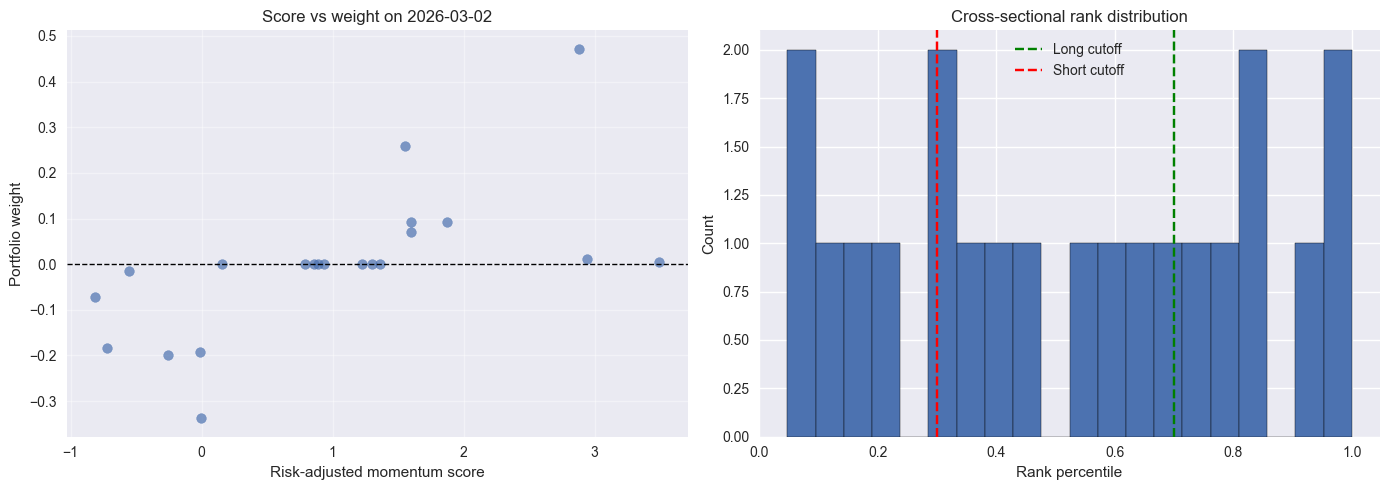

In [20]:
# Cross-sectional relationship between risk-adjusted score and weight

example_date = latest_date  # reuse latest_date from above
example_diag = diag.xs(example_date, level="date")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: score vs weight
ax[0].scatter(example_diag["mom_score"], example_diag["weight"], alpha=0.7)
ax[0].axhline(0, color="black", linewidth=1, linestyle="--")
ax[0].set_xlabel("Risk-adjusted momentum score")
ax[0].set_ylabel("Portfolio weight")
ax[0].set_title(f"Score vs weight on {example_date.date()}")
ax[0].grid(True, alpha=0.4)

# Histogram of rank percentiles
ax[1].hist(example_diag["rank_pct"], bins=20, edgecolor="black")
ax[1].axvline(0.7, color="green", linestyle="--", label="Long cutoff")
ax[1].axvline(0.3, color="red", linestyle="--", label="Short cutoff")
ax[1].set_xlabel("Rank percentile")
ax[1].set_ylabel("Count")
ax[1].set_title("Cross-sectional rank distribution")
ax[1].legend()

plt.tight_layout()
plt.show()